In [ ]:
import zipfile
import os

# 1. Sửa lại đường dẫn trực tiếp trên Colab (bỏ đoạn drive/MyDrive)
zip_path = "/content/drive/MyDrive/Vietnamese_StreetFood_14Class.zip"
extract_path = "/content/food_datasets/"

# 2. Tiến hành giải nén tự động
if not os.path.exists(extract_path):
    print("Đang giải nén dữ liệu, vui lòng đợi...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Giải nén thành công vào thư mục:", extract_path)
else:
    print("Dữ liệu đã được giải nén từ trước.")


Đang giải nén dữ liệu, vui lòng đợi...
Giải nén thành công vào thư mục: /content/food_datasets/


In [ ]:
import os
import shutil

root_path = "/content/food_datasets"
class_names = [
    "Banh_mi", "Pho", "Bun_cha", "Nem_ran", "Com_tam",
    "Banh_cuon", "Bun_bo_Hue", "My_quang", "Goi_cuon", "Banh_xeo",
    "Chao_long", "Hu_tieu", "Bun_rieu", "Ca_kho_to"
]

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(root_path, split, 'images')
    lbl_dir = os.path.join(root_path, split, 'labels')

    if not os.path.exists(img_dir):
        continue

    print(f"🔄 Đang phân loại tập [{split.upper()}]...")
    for img_name in os.listdir(img_dir):
        if img_name.startswith('.'): continue

        img_src = os.path.join(img_dir, img_name)
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        lbl_src = os.path.join(lbl_dir, lbl_name)

        class_id = 0
        if os.path.exists(lbl_src) and os.path.getsize(lbl_src) > 0:
            with open(lbl_src, 'r') as f:
                line = f.readline().strip()
                if line: class_id = int(line.split()[0])

        if class_id >= len(class_names): class_id = 0

        target_dir = os.path.join(root_path, split, class_names[class_id])
        os.makedirs(target_dir, exist_ok=True)
        shutil.move(img_src, os.path.join(target_dir, img_name))

    shutil.rmtree(img_dir, ignore_errors=True)
    shutil.rmtree(lbl_dir, ignore_errors=True)

# Xóa bỏ file cấu hình lẻ ở thư mục gốc để tránh lỗi NotADirectoryError của Keras
if os.path.exists(os.path.join(root_path, "data.yaml")):
    os.remove(os.path.join(root_path, "data.yaml"))

print("✨ Đã chuẩn hóa cấu trúc dữ liệu CNN!")


🔄 Đang phân loại tập [TRAIN]...
🔄 Đang phân loại tập [VALID]...
🔄 Đang phân loại tập [TEST]...
✨ Đã chuẩn hóa cấu trúc dữ liệu CNN!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# CHỈ ĐỊNH ĐƯỜNG DẪN ĐẾN THƯ MỤC CON CHỨA 14 CLASS
train_dir = "/content/food_datasets/train"
validation_dir = "/content/food_datasets/valid"

# Cấu hình các tham số ảnh
img_width, img_height = 240, 240
batch_size = 32

# Khởi tạo Generator (Ví dụ cơ bản)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),  # Giảm overfitting
    Dense(14, activation="softmax")
])


Found 1385 images belonging to 14 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

# 2. Khởi tạo bộ chuẩn hóa ảnh (chia pixel cho 255 giống tập train)
validation_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# 3. Tạo bộ phát dữ liệu kiểm định
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)


Found 1071 images belonging to 14 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 238, 238, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 119, 119, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 117, 117, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 58, 58, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,238 (49.36 MB)

 Trainable params: 12,940,238 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.1899 - loss: 2.3894 - val_accuracy: 0.2316 - val_loss: 2.2210
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 269s 6s/step - accuracy: 0.2527 - loss: 2.2398 - val_accuracy: 0.2680 - val_loss: 2.1067
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 287s 7s/step - accuracy: 0.2708 - loss: 2.1742 - val_accuracy: 0.2801 - val_loss: 2.0727
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 271s 6s/step - accuracy: 0.2801 - loss: 2.1022 - val_accuracy: 0.3175 - val_loss: 1.9722
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 272s 6s/step - accuracy: 0.3032 - loss: 2.0745 - val_accuracy: 0.3296 - val_loss: 1.9116
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 293s 7s/step - accuracy: 0.3256 - loss: 2.0090 - val_accuracy: 0.3557 - val_loss: 1.9193
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 323s 7s/step - accuracy: 0.3256 - loss: 1.9768 - val_accuracy: 0.3427 - val_loss: 1.9299
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 278s 6s/step - accuracy: 0.3458 - loss: 1.9612 - val_accuracy: 0.3483 - v

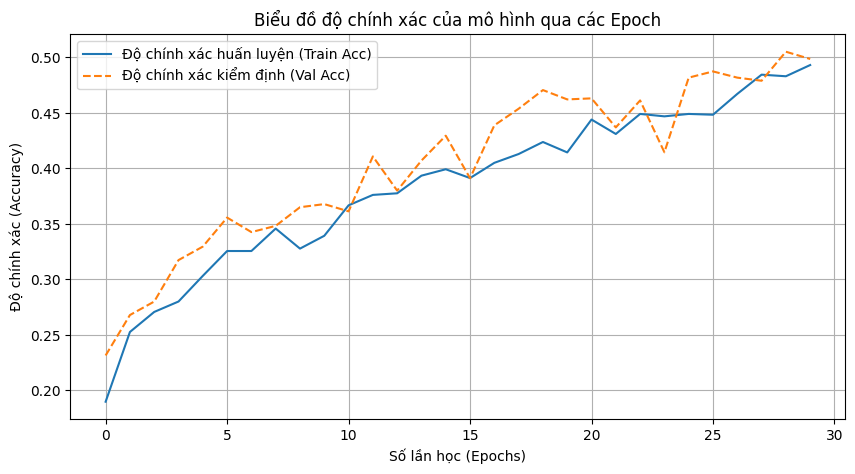

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Biến dịch mô hình
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Tóm tắt cấu hình của mô hình (Kiểm tra lại xem Output Layer đã là 14 chưa)
model.summary()

callbacks_list = [
    # Tự động dừng nếu độ chính xác trên tập validation (val_loss) không cải thiện sau 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    # Tự động lưu lại mô hình có kết quả tốt nhất trong quá trình chạy
    ModelCheckpoint(
        filepath='best_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]
# 2. HUẤN LUYỆN MÔ HÌNH CNN
# Bổ sung validation_data để theo dõi độ chính xác trên tập kiểm định, tránh overfitting
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator  # Thêm dòng này nếu bạn đã tạo validation_generator ở bước trước
)

# 3. ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH (Vẽ biểu đồ độ chính xác)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label="Độ chính xác huấn luyện (Train Acc)")

# Nếu có tập validation thì vẽ thêm đường đồ thị validation để so sánh
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác kiểm định (Val Acc)", linestyle='--')

plt.title("Biểu đồ độ chính xác của mô hình qua các Epoch")
plt.xlabel("Số lần học (Epochs)")
plt.ylabel("Độ chính xác (Accuracy)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Đổi tên thành phiên bản v2 hoặc thêm chữ _hoanthanh
model.save('/content/mo_hinh_cnn_30_epochs_v2.keras')

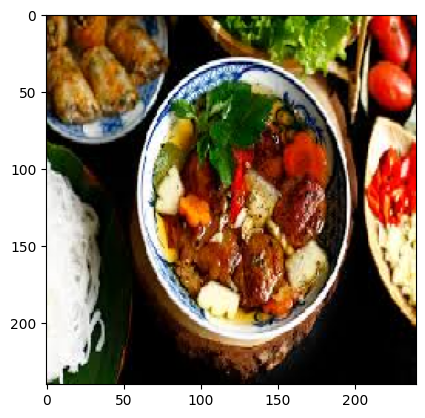

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Món ăn: Nem_ran


In [12]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np

path = "/content/bun_cha.jpg"

# Tiên đoán loại s
img = load_img(path, target_size=(240, 240))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 240, 240, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
Mon_an = class_labels[prediction]
print(f"Món ăn: {Mon_an}")